In [1]:
# Install the required libraries
!pip install xformers peft accelerate bitsandbytes transformers trl unsloth_zoo unsloth

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

# Authenticate Hugging Face using Kaggle Secrets
try:
    user_secrets = UserSecretsClient()
    hf_token = user_secrets.get_secret("HF_TOKEN")
    login(token=hf_token)
    print("Successfully logged in to Hugging Face!")
except Exception as e:
    print("WARNING: HF_TOKEN not found. Please add it in the Kaggle Secrets sidebar.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 4.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of unsloth-zoo to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of unsloth-zoo to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 46.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/

In [2]:
import torch
from unsloth import FastLanguageModel

MODEL_ID = "unsloth/Phi-3-mini-4k-instruct" # Using the pre-quantized Unsloth version
MAX_SEQ_LENGTH = 2048

def load_phi3_model_unsloth(model_id: str):
    print(f"Loading {model_id} via Unsloth...")
    
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = model_id,
        max_seq_length = MAX_SEQ_LENGTH,
        dtype = torch.float16, # T4 requires float16
        load_in_4bit = True,   # Uses 4-bit quantization without the typical BNB errors
    )

    # Adding chemical tokens
    print("Adding custom SMILES and chemical tokens...")
    # These represent the most common structural elements in SMILES strings
    chemical_tokens = ["[", "]", "(", ")", "=", "#", "@", "@@", "+", "-", "/", "\\", "se", "te", "Si"]
    
    num_added = tokenizer.add_tokens(chemical_tokens)
    print(f"Added {num_added} new tokens to the tokenizer.")
    
    # Resize the model's vocabulary to match the new tokenizer size
    model.resize_token_embeddings(len(tokenizer), pad_to_multiple_of=64)

    print("Applying LoRA adapter via Unsloth...")
    model = FastLanguageModel.get_peft_model(
        model,
        r = 64,           # Factual injection requires higher rank.
        lora_alpha = 64,  # Usually set equal to 'r' or 2*r in Unsloth
        target_modules = [
            "q_proj", "k_proj", "v_proj", "o_proj",
            "gate_proj", "up_proj", "down_proj",
            "embed_tokens", "lm_head",
        ],
        lora_dropout = 0, # Unsloth optimization: 0 is better for performance
        bias = "none",    # Unsloth optimization: "none" is better
        use_gradient_checkpointing = "unsloth", # Much more memory efficient
        random_state = 3407,
    )

    return model, tokenizer

model, tokenizer = load_phi3_model_unsloth(MODEL_ID)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2026-04-27 11:04:13.213130: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777287853.440837      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777287853.506918      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777287854.029950      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777287854.029992      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777287854.029995      55 computation_placer.cc:177] computation placer alr

🦥 Unsloth Zoo will now patch everything to make training faster!
Loading unsloth/Phi-3-mini-4k-instruct via Unsloth...
==((====))==  Unsloth 2026.4.8: Fast Mistral patching. Transformers: 4.57.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.26G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/194 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/458 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Adding custom SMILES and chemical tokens...
Added 15 new tokens to the tokenizer.
Applying LoRA adapter via Unsloth...
Unsloth: Offloading input_embeddings to disk to save VRAM


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1225: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)
Unsloth 2026.4.8 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


Unsloth: Training embed_tokens in mixed precision to save VRAM


In [3]:
from datasets import load_dataset
import json
import os
import re
import random
import ast

random.seed(42)

def deduplicate_descriptions(descriptions_dict):
    """Uses TF-IDF and Cosine Similarity to remove redundant sentences from multiple sources."""
    if not isinstance(descriptions_dict, dict):
        return ""
    
    valid_texts = [clean_text(str(v)) for v in descriptions_dict.values() if is_valid_value(v)]
    if not valid_texts:
        return ""
        
    combined_text = " ".join(valid_texts)
    # Basic sentence splitter
    sentences = re.split(r'(?<=[.!?])\s+', combined_text)
    sentences = [s.strip() for s in sentences if len(s) > 10]
    
    if len(sentences) <= 1:
        return combined_text

    try:
        # Calculate TF-IDF matrix for the sentences
        vectorizer = TfidfVectorizer().fit_transform(sentences)
        vectors = vectorizer.toarray()
        cosine_matrix = cosine_similarity(vectors)

        unique_sentences = []
        for i in range(len(sentences)):
            is_duplicate = False
            # Compare current sentence to all previously accepted sentences
            for j in range(i):
                if cosine_matrix[i][j] > 0.70:  # 70% similarity threshold
                    is_duplicate = True
                    break
            if not is_duplicate:
                unique_sentences.append(sentences[i])
                
        return " ".join(unique_sentences)
    except Exception:
        # Fallback if TF-IDF fails (e.g., empty vocabulary)
        return combined_text

def to_subscript(formula):
    """Converts numbers in chemical formulas to Unicode subscripts."""
    if not isinstance(formula, str) or not formula:
        return formula
    subscript_map = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
    return formula.translate(subscript_map)

def clean_text(text):
    """Basic NLP cleaning: removes extra whitespaces, newline artifacts, and boilerplate."""
    if not isinstance(text, str) or not text:
        return text
    
    text = re.sub(r'(?i)[^.]*listed in the ChEMBL database[^.]*\.', '', text)
    text = re.sub(r'(?i)[^.]*clinical trial phase[^.]*\.', '', text)
    text = re.sub(r'\[\d+\]', '', text)
    
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def is_valid_value(val):
    """Checks whether a value is effectively null or empty."""
    if val is None:
        return False
    if isinstance(val, str):
        val_lower = val.strip().lower()
        if val_lower in ["", "null", "none", "n/a", "na", "unknown", "[]", "{}"]:
            return False
    return True

def safe_json_loads(value):
    """Safely parse JSON-like fields coming from the dataset."""
    if isinstance(value, dict):
        return value
    if isinstance(value, str):
        try:
            parsed = json.loads(value)
            return parsed if isinstance(parsed, dict) else {}
        except json.JSONDecodeError:
            return {}
    return {}

def parse_synonyms(value):
    """Safely parse the synonyms list."""
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            # Handle stringified lists like "['syn1', 'syn2']"
            parsed = ast.literal_eval(value)
            return parsed if isinstance(parsed, list) else []
        except (ValueError, SyntaxError):
            return []
    return []

def extract_first_sentence(text):
    if not isinstance(text, str) or not text.strip():
        return ""
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return parts[0].strip()

def prepare_smart_chem_dataset(tokenizer, max_molecules=2000, max_questions_per_molecule=5):
    print("Downloading JAZL/ChemGist-CHON...")
    dataset = load_dataset("JAZL/ChemGist-CHON", split="train")

    limit = min(max_molecules, len(dataset))
    dataset = dataset.shuffle(seed=42).select(range(limit))

    def format_chem_batch(batch):
        augmented_texts = []
        eos = tokenizer.eos_token or "<|end|>"

        # Helper to format text strictly in Phi-3 conversational structure
        def build_chat(user_query, assistant_response):
            return f"<|user|>\n{user_query}<|end|>\n<|assistant|>\n{assistant_response}{eos}"

        common_names = batch.get("common_name", [])
        smiles_list = batch.get("canonical_smiles", [])
        inchikey_list = batch.get("inchikey", [])
        synonyms_raw_list = batch.get("synonyms_list", [])

        for i in range(len(common_names)):
            common_name = clean_text(common_names[i])
            smiles = clean_text(smiles_list[i])
            inchikey = clean_text(inchikey_list[i] if i < len(inchikey_list) else "")
            
            if not is_valid_value(common_name):
                continue

            theo_raw = batch.get("theoretical_properties", ["{}"])[i]
            phys_raw = batch.get("physical_properties", ["{}"])[i]
            desc_raw = batch.get("descriptions", ["{}"])[i]
            syn_raw = synonyms_raw_list[i] if i < len(synonyms_raw_list) else "[]"

            theo_props = safe_json_loads(theo_raw)
            phys_props = safe_json_loads(phys_raw)
            descriptions = safe_json_loads(desc_raw)
            synonyms = parse_synonyms(syn_raw)

            # Clean and validate synonyms
            valid_syns = [clean_text(s) for s in synonyms if is_valid_value(s)][:5] # Limit to top 5 to avoid overflow

            guaranteed_pool = []
            random_pool = []
            profile_parts = []

            # ==========================================
            # 1. CORE IDENTIFIERS (Guaranteed & Random)
            # ==========================================
            if is_valid_value(smiles):
                # Put the "What is the SMILES" in the random pool
                random_pool.append(build_chat(f"What is the canonical SMILES sequence for {common_name}?", f"The canonical SMILES sequence for {common_name} is {smiles}."))
                # Put the reverse question in the random pool
                random_pool.append(build_chat(f"Identify the chemical with the SMILES structure: {smiles}", f"The chemical with the SMILES structure {smiles} is {common_name}."))
                profile_parts.append(f"SMILES: {smiles}")

            if is_valid_value(inchikey):
                random_pool.append(build_chat(f"What is the InChIKey for {common_name}?", f"The InChIKey for {common_name} is {inchikey}."))
                profile_parts.append(f"InChIKey: {inchikey}")

            if valid_syns:
                syn_str = ", ".join(valid_syns)
                random_pool.append(build_chat(f"What are some synonyms or alternative names for {common_name}?", f"Some known synonyms for {common_name} include: {syn_str}."))

            # ==========================================
            # 2. THEORETICAL PROPERTIES
            # ==========================================
            theo_sentences = []
            if isinstance(theo_props, dict):
                for k, v in theo_props.items():
                    if not is_valid_value(v): continue
                    display_v = to_subscript(str(v)) if k == "molecular_formula" else str(v)
                    clean_k = k.replace("_", " ")
                    
                    random_pool.append(build_chat(f"What is the {clean_k} of {common_name}?", f"The {clean_k} of {common_name} is {display_v}."))
                    theo_sentences.append(f"its {clean_k} is {display_v}")
                
                if theo_sentences:
                    # Join them intelligently with commas and an 'and'
                    if len(theo_sentences) > 1:
                        theo_block = f"Regarding its theoretical properties, {', '.join(theo_sentences[:-1])}, and {theo_sentences[-1]}."
                    else:
                        theo_block = f"Regarding its theoretical properties, {theo_sentences[0]}."
                    
                    # Capitalize first letter properly
                    theo_block = theo_block[0].upper() + theo_block[1:]
                    
                    random_pool.append(build_chat(f"Provide the theoretical properties of {common_name}.", theo_block))
                    profile_parts.append(theo_block)

            # ==========================================
            # 3. PHYSICAL PROPERTIES
            # ==========================================
            phys_sentences = []
            if isinstance(phys_props, dict):
                for k, v in phys_props.items():
                    if not is_valid_value(v): continue
                    cleaned_v = clean_text(re.sub(r"\s*\([a-zA-Z]+\s*,\s*\d{4}\)", "", str(v)))
                    clean_k = k.replace("_", " ")
                    
                    random_pool.append(build_chat(f"What is the {clean_k} of {common_name}?", f"The {clean_k} of {common_name} is {cleaned_v}."))
                    phys_sentences.append(f"its {clean_k} is {cleaned_v}")

                if phys_sentences:
                    if len(phys_sentences) > 1:
                        phys_block = f"Physically, {', '.join(phys_sentences[:-1])}, and {phys_sentences[-1]}."
                    else:
                        phys_block = f"Physically, {phys_sentences[0]}."
                    
                    phys_block = phys_block[0].upper() + phys_block[1:]
                    
                    random_pool.append(build_chat(f"List the physical properties of {common_name}.", phys_block))
                    profile_parts.append(phys_block)

            # ==========================================
            # 4. DESCRIPTIONS
            # ==========================================
            combined_desc = clean_text(deduplicate_descriptions(descriptions))
            if is_valid_value(combined_desc):
                random_pool.append(build_chat(f"Describe {common_name}.", f"Here is a description of {common_name}:\n{combined_desc}"))
                profile_parts.append(f"Description: {combined_desc}")

                # RAG simulation training to teach the model to answer based on provided context
                rag_prompt = f"Using the following database excerpt, describe the chemical {common_name}.\n\nContext: {combined_desc}"
                rag_answer = f"Based on the provided context, {common_name} can be described as follows: {combined_desc}"
                random_pool.append(build_chat(rag_prompt, rag_answer))

            # ==========================================
            # 5. FULL CHEMICAL PROFILE (GUARANTEED)
            # ==========================================
            if profile_parts:
                profile_ans = "\n\n".join(profile_parts)
                # The massive summary is GUARANTEED to be included.
                # This ensures 100% of the dataset's knowledge is injected into the model.
                guaranteed_pool.append(build_chat(
                    f"Detail the complete chemical profile of {common_name}.", 
                    f"Here is the comprehensive profile for {common_name}:\n\n{profile_ans}"
                ))

            # ==========================================
            # AGGREGATE TEXTS
            # ==========================================
            
            # 1. ALWAYS add the guaranteed pool (the massive profile)
            augmented_texts.extend(guaranteed_pool)
            
            # 2. Add a few specific Q/A pairs to teach it HOW to answer specific questions
            if random_pool:
                selected_random = random.sample(random_pool, min(max_questions_per_molecule, len(random_pool)))
                augmented_texts.extend(selected_random)

        return {"text": augmented_texts}

    print("Formatting and augmenting text with full property combinations...")
    num_proc = max(1, min((os.cpu_count() or 2), 4))
    return dataset.map(
        format_chem_batch,
        batched=True,
        remove_columns=dataset.column_names,
        num_proc=num_proc,
        desc="Preparing chemical training text",
    )

# Increased max_questions_per_molecule since our pool is now massive
raw_text_dataset = prepare_smart_chem_dataset(tokenizer, max_molecules=10000, max_questions_per_molecule=4)
print(raw_text_dataset)
print("\nSample Output:")
print(raw_text_dataset[0]['text'])

README.md: 0.00B [00:00, ?B/s]

ChemGist-CHON.csv:   0%|          | 0.00/25.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8574 [00:00<?, ? examples/s]

Formatting and augmenting text with full property combinations...


Preparing chemical training text (num_proc=4):   0%|          | 0/8574 [00:00<?, ? examples/s]

Dataset({
    features: ['text'],
    num_rows: 37045
})

Sample Output:
<|user|>
Detail the complete chemical profile of Iproheptine.<|end|>
<|assistant|>
Here is the comprehensive profile for Iproheptine:

SMILES: N(C(CCCC(C)C)C)C(C)C

InChIKey: NKGYBXHAQAKSSG-UHFFFAOYSA-N

Regarding its theoretical properties, its molecular formula is C₁₁H₂₅N, its molecular weight is 171.32 g/mol, its exact mass is 171.198699802 g/mol, its formal charge is 0, its hydrogen bond donor count is 1, its hydrogen bond acceptor count is 1, its rotatable bond count is 6, its heavy atom count is 12, its topological polar surface area is 12 Å², its isotope atom count is 0, and its covalently bonded unit count is 1.

Description: Iproheptine is a secondary amino compound. 0. Iproheptine, also known as N-isopropyl-1,5-dimethylhexylamine or N-isopropyloctodrine and sold under the brand names Metron and Susat, is a nasal decongestant which has been marketed in Japan. It is described as a vasoconstrictor and antih

In [4]:
from trl import SFTTrainer, SFTConfig
import torch
import gc
import os
from transformers.trainer_utils import get_last_checkpoint

def run_fast_fine_tuning(model, tokenizer, dataset):
    # Keep training stable and memory-efficient.
    model.config.use_cache = False

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
    
    OUTPUT_DIR = "/kaggle/working/chem-llm-results"

    training_args = SFTConfig(
        output_dir=OUTPUT_DIR,
        num_train_epochs=3,
        per_device_train_batch_size=4, 
        gradient_accumulation_steps=2, 
        learning_rate=2e-4, 
        lr_scheduler_type="cosine",
        warmup_steps=25,
        logging_steps=10,
        
        save_strategy="steps", 
        save_steps=50,
        save_total_limit=2, 
        
        report_to="none",
        optim="adamw_8bit",
        bf16=use_bf16,
        fp16=not use_bf16,
        gradient_checkpointing=True,
        dataset_num_proc=max(1, min((os.cpu_count() or 2), 4)),
        packing=True,
        max_seq_length=512,
        dataloader_num_workers=max(1, min((os.cpu_count() or 2), 4)),
        dataloader_pin_memory=True,
    )

    def formatting_func(example):
        return example["text"]

    trainer = SFTTrainer(
        model=model,
        args=training_args,
        train_dataset=dataset,
        processing_class=tokenizer,
        formatting_func=formatting_func,
    )

    last_checkpoint = None
    if os.path.isdir(OUTPUT_DIR):
        last_checkpoint = get_last_checkpoint(OUTPUT_DIR)

    if last_checkpoint is not None:
        print(f"Resuming training from checkpoint: {last_checkpoint}")
        trainer.train(resume_from_checkpoint=last_checkpoint)
    else:
        print("Starting Optimized Fine-Tuning from scratch...")
        trainer.train()
        
    print("Fine-Tuning Complete!")
    return trainer

trainer_obj = run_fast_fine_tuning(model, tokenizer, raw_text_dataset)

Unsloth: Tokenizing ["text"] (num_proc=4):   0%|          | 0/37045 [00:00<?, ? examples/s]

Unsloth: Packing train dataset (num_proc=4):   0%|          | 0/37045 [00:00<?, ? examples/s]

🦥 Unsloth: Packing enabled - training is >2x faster and uses less VRAM!
Starting Optimized Fine-Tuning from scratch...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 2
   \\   /|    Num examples = 11,317 | Num Epochs = 3 | Total steps = 4,245
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 220,286,976 of 4,041,366,528 (5.45% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
10,1.723600
20,1.309500
30,1.049400
40,0.962300
50,0.869100
60,0.864400
70,0.832200
80,0.814400
90,0.806600
100,0.795600


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:279: UserWarning: Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.
  warnings.warn("Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.")
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:279: UserWarning: Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.
  warnings.warn("Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.")
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:279: UserWarning: Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.
  warnings.warn("Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.")
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:279: UserWarning: Setting `save_embedding_layers` to `True` as embedding layers fou

Fine-Tuning Complete!


Fetching 100 unseen chemicals for evaluation...

Evaluating 100 questions...


Running Inference: 100%|██████████| 100/100 [23:41<00:00, 14.21s/it]



EVALUATION COMPLETE - DYNAMIC ANALYSIS
Total Evaluated: 100
> Improved Answers (FT beat Base): 100
> Degraded Answers (Base beat FT): 0
> Neutral/Unchanged: 0


/tmp/ipykernel_55/2058908871.py:152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=melted_f1, x='Model', y='F1 Score', palette=['red', 'green'], ax=ax4)


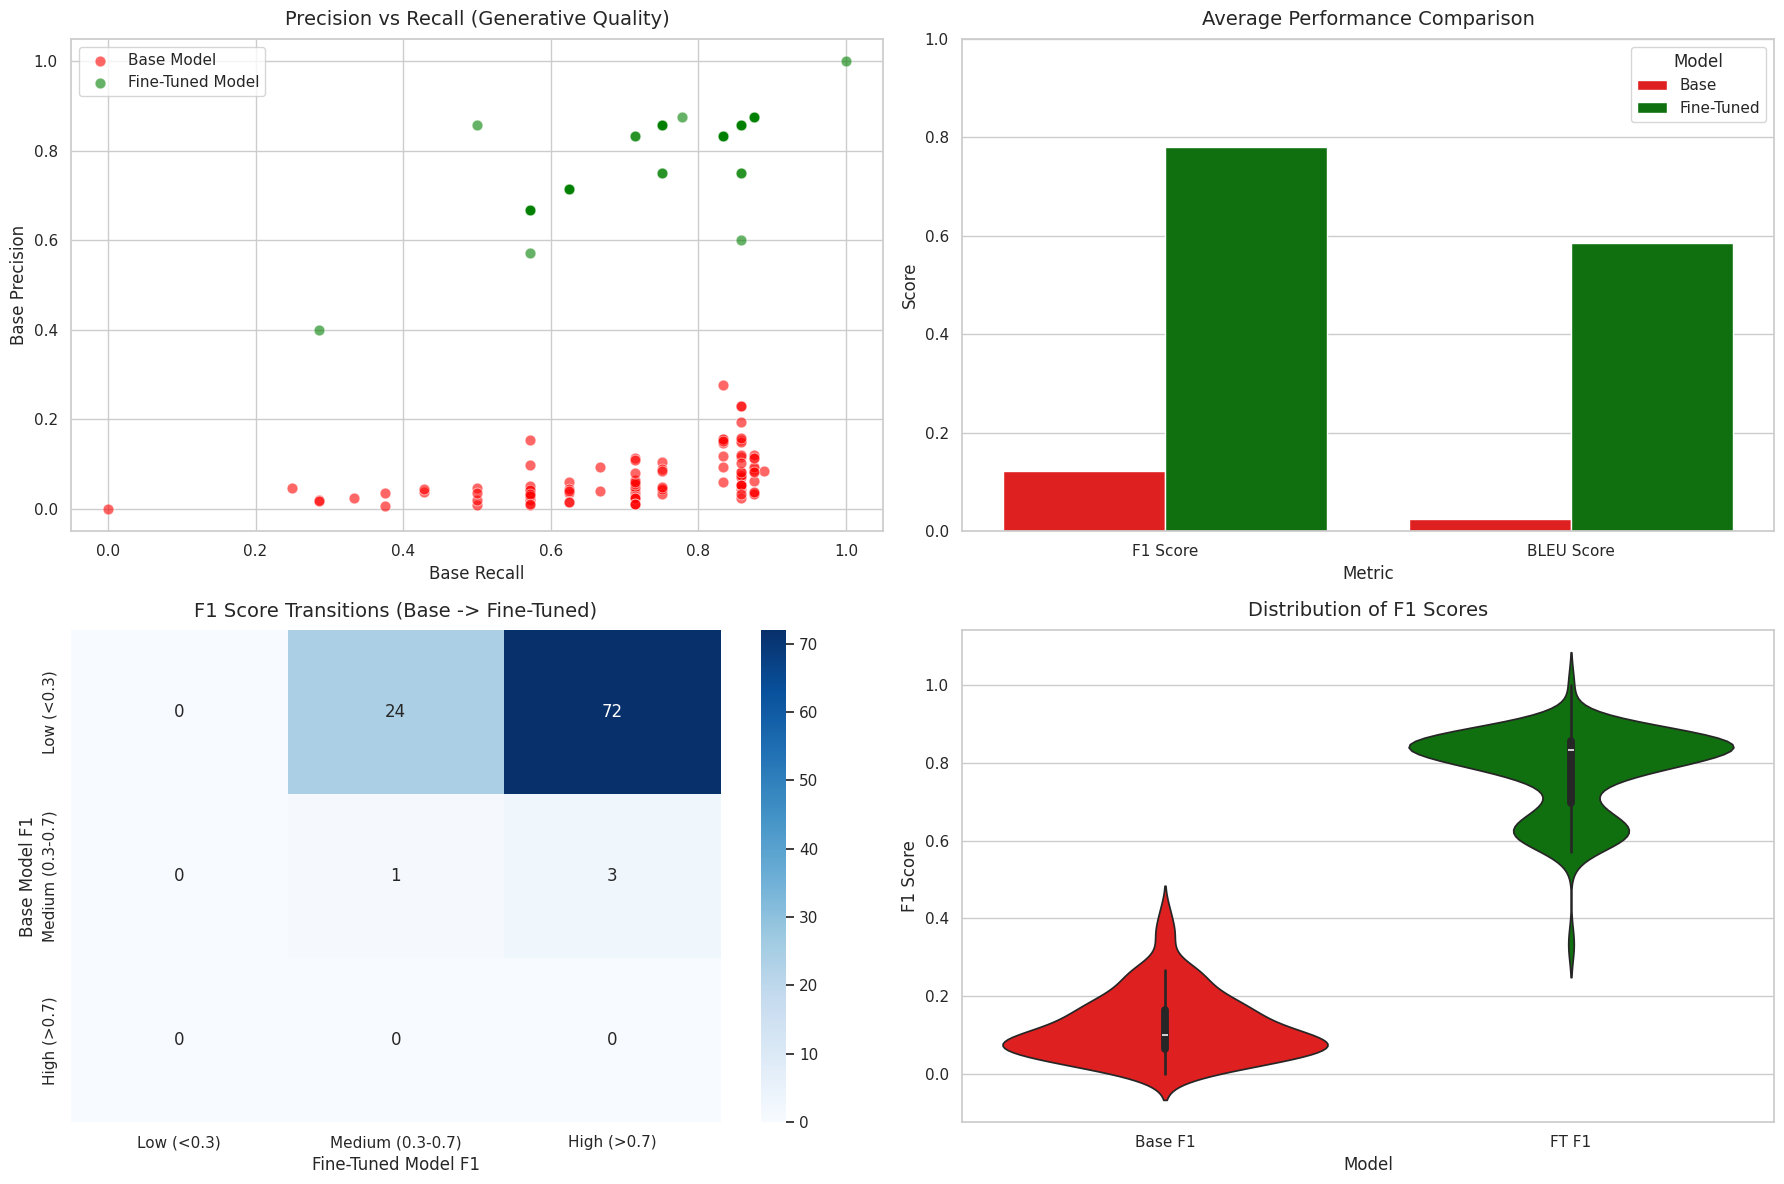

In [5]:
import torch
import re
import collections
import json
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from datasets import load_dataset
from unsloth import FastLanguageModel
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Download necessary NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# ==========================================
# 1. METRIC HELPER FUNCTIONS
# ==========================================
def normalize_answer(s):
    def remove_articles(text): return re.sub(r'\b(a|an|the)\b', ' ', text)
    def white_space_fix(text): return ' '.join(text.split())
    def remove_punc(text):
        exclude = set('!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~')
        return ''.join(ch for ch in text if ch not in exclude)
    return white_space_fix(remove_articles(remove_punc(str(s).lower())))

def get_tokens(s):
    if not s: return []
    return normalize_answer(s).split()

def compute_f1(a_gold, a_pred):
    gold_toks = get_tokens(a_gold)
    pred_toks = get_tokens(a_pred)
    common = collections.Counter(gold_toks) & collections.Counter(pred_toks)
    num_same = sum(common.values())
    if len(gold_toks) == 0 or len(pred_toks) == 0:
        return int(gold_toks == pred_toks), int(gold_toks == pred_toks), int(gold_toks == pred_toks)
    if num_same == 0:
        return 0.0, 0.0, 0.0
    precision = 1.0 * num_same / len(pred_toks)
    recall = 1.0 * num_same / len(gold_toks)
    f1 = (2 * precision * recall) / (precision + recall)
    return precision, recall, f1

def compute_bleu(a_gold, a_pred):
    reference = [get_tokens(a_gold)]
    candidate = get_tokens(a_pred)
    smoothie = SmoothingFunction().method4
    return sentence_bleu(reference, candidate, smoothing_function=smoothie)

# ==========================================
# 2. DYNAMIC EVALUATION SET GENERATOR
# ==========================================
def generate_dynamic_eval_set(num_samples=50):
    print(f"Fetching {num_samples} unseen chemicals for evaluation...")
    # Load from the BACK of the dataset to avoid training overlap
    dataset = load_dataset("JAZL/ChemGist-CHON", split=f"train[-{num_samples * 5}:]") 
    
    eval_pairs = []
    subscript_map = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
    
    for row in dataset:
        if len(eval_pairs) >= num_samples: break
        
        common_name = str(row.get("common_name", "")).strip()
        if not common_name or common_name.lower() in ["none", "null", ""]: continue
        
        smiles = str(row.get("canonical_smiles", "")).strip()
        
        theo_raw = row.get("theoretical_properties", "{}")
        try: theo_props = json.loads(theo_raw) if isinstance(theo_raw, str) else theo_raw
        except: theo_props = {}
        
        weight = theo_props.get("molecular_weight", "")
        formula = theo_props.get("molecular_formula", "")
        
        # Pick ONE random fact per chemical to test
        q_type = random.choice(["smiles", "weight", "formula", "identify"])
        
        if q_type == "smiles" and smiles and smiles.lower() != "none":
            eval_pairs.append({
                "question": f"What is the canonical SMILES sequence for {common_name}?",
                "expected": f"The canonical SMILES sequence for {common_name} is {smiles}."
            })
        elif q_type == "weight" and weight and str(weight).lower() != "none":
            eval_pairs.append({
                "question": f"What is the molecular weight of {common_name}?",
                "expected": f"The molecular weight of {common_name} is {weight}."
            })
        elif q_type == "formula" and formula and str(formula).lower() != "none":
            formula_sub = str(formula).translate(subscript_map)
            eval_pairs.append({
                "question": f"What is the molecular formula of {common_name}?",
                "expected": f"The molecular formula of {common_name} is {formula_sub}."
            })
        elif q_type == "identify" and smiles and smiles.lower() != "none":
            eval_pairs.append({
                "question": f"Identify the chemical with the SMILES structure: {smiles}",
                "expected": f"The chemical with the SMILES structure {smiles} is {common_name}."
            })
            
    return eval_pairs

# ==========================================
# 3. VISUALIZATION DASHBOARD
# ==========================================
def plot_evaluation_dashboard(results_df):
    sns.set_theme(style="whitegrid")
    fig = plt.figure(figsize=(18, 12))
    
    # Plot 1: Precision vs Recall Scatter
    ax1 = plt.subplot(2, 2, 1)
    sns.scatterplot(data=results_df, x='Base Recall', y='Base Precision', label='Base Model', color='red', alpha=0.6, s=60, ax=ax1)
    sns.scatterplot(data=results_df, x='FT Recall', y='FT Precision', label='Fine-Tuned Model', color='green', alpha=0.6, s=60, ax=ax1)
    ax1.set_title('Precision vs Recall (Generative Quality)', fontsize=14, pad=10)
    ax1.set_xlim(-0.05, 1.05)
    ax1.set_ylim(-0.05, 1.05)
    
    # Plot 2: Average Metrics Bar Chart
    ax2 = plt.subplot(2, 2, 2)
    avg_metrics = pd.DataFrame({
        'Metric': ['F1 Score', 'F1 Score', 'BLEU Score', 'BLEU Score'],
        'Score': [results_df['Base F1'].mean(), results_df['FT F1'].mean(), results_df['Base BLEU'].mean(), results_df['FT BLEU'].mean()],
        'Model': ['Base', 'Fine-Tuned', 'Base', 'Fine-Tuned']
    })
    sns.barplot(data=avg_metrics, x='Metric', y='Score', hue='Model', palette=['red', 'green'], ax=ax2)
    ax2.set_title('Average Performance Comparison', fontsize=14, pad=10)
    ax2.set_ylim(0, 1.0)
    
    # Plot 3: Performance Shift "Confusion Matrix"
    ax3 = plt.subplot(2, 2, 3)
    # Bucket the F1 scores into Low, Medium, High
    bins = [-0.1, 0.3, 0.7, 1.0]
    labels = ['Low (<0.3)', 'Medium (0.3-0.7)', 'High (>0.7)']
    results_df['Base Bucket'] = pd.cut(results_df['Base F1'], bins=bins, labels=labels)
    results_df['FT Bucket'] = pd.cut(results_df['FT F1'], bins=bins, labels=labels)
    
    # Create crosstab
    shift_matrix = pd.crosstab(results_df['Base Bucket'], results_df['FT Bucket'], rownames=['Base Model F1'], colnames=['Fine-Tuned Model F1'])
    # Reindex to ensure all categories are present and ordered
    shift_matrix = shift_matrix.reindex(index=labels, columns=labels, fill_value=0)
    
    sns.heatmap(shift_matrix, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=True)
    ax3.set_title('F1 Score Transitions (Base -> Fine-Tuned)', fontsize=14, pad=10)
    
    # Plot 4: F1 Score Distribution Violin Plot
    ax4 = plt.subplot(2, 2, 4)
    melted_f1 = results_df[['Base F1', 'FT F1']].melt(var_name='Model', value_name='F1 Score')
    sns.violinplot(data=melted_f1, x='Model', y='F1 Score', palette=['red', 'green'], ax=ax4)
    ax4.set_title('Distribution of F1 Scores', fontsize=14, pad=10)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 4. MAIN EVALUATION LOOP
# ==========================================
def evaluate_and_visualize(model, tokenizer, num_samples=50):
    qa_pairs = generate_dynamic_eval_set(num_samples)
    print(f"\nEvaluating {len(qa_pairs)} questions...")

    model.to("cuda")
    FastLanguageModel.for_inference(model)
    results = []

    for i, pair in enumerate(tqdm(qa_pairs, desc="Running Inference")):
        question = pair["question"]
        expected = pair["expected"]
        
        prompt = f"<|user|>\n{question}<|end|>\n<|assistant|>\n"
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

        # 1. BASELINE
        with model.disable_adapter():
            base_outputs = model.generate(
                **inputs, max_new_tokens=1024, pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id, temperature=0.1, top_p=0.9,
                repetition_penalty=1.05, do_sample=True, use_cache=True
            )
            base_answer = tokenizer.decode(base_outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()

        # 2. FINE-TUNED
        ft_outputs = model.generate(
            **inputs, max_new_tokens=1024, pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id, temperature=0.1, top_p=0.9,
            repetition_penalty=1.05, do_sample=True, use_cache=True
        )
        ft_answer = tokenizer.decode(ft_outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()

        # 3. METRICS
        b_prec, b_rec, b_f1 = compute_f1(expected, base_answer)
        f_prec, f_rec, f_f1 = compute_f1(expected, ft_answer)
        b_bleu = compute_bleu(expected, base_answer)
        f_bleu = compute_bleu(expected, ft_answer)

        results.append({
            "Question": question,
            "Expected": expected,
            "Base Answer": base_answer,
            "FT Answer": ft_answer,
            "Base Precision": b_prec, "Base Recall": b_rec, "Base F1": b_f1, "Base BLEU": b_bleu,
            "FT Precision": f_prec,   "FT Recall": f_rec,   "FT F1": f_f1,   "FT BLEU": f_bleu
        })

    results_df = pd.DataFrame(results)
    
    print("\n" + "="*60)
    print("EVALUATION COMPLETE - DYNAMIC ANALYSIS")
    print("="*60)
    
    improved = len(results_df[results_df['FT F1'] > results_df['Base F1'] + 0.1])
    degraded = len(results_df[results_df['Base F1'] > results_df['FT F1'] + 0.1])
    neutral = len(results_df) - improved - degraded
    
    print(f"Total Evaluated: {len(results_df)}")
    print(f"> Improved Answers (FT beat Base): {improved}")
    print(f"> Degraded Answers (Base beat FT): {degraded}")
    print(f"> Neutral/Unchanged: {neutral}")
    
    # Draw Visualizations
    plot_evaluation_dashboard(results_df)
    
    return results_df

# Execute the evaluation on 100 dynamic questions
results_dataframe = evaluate_and_visualize(model, tokenizer, num_samples=100)

In [6]:
import re
from unsloth import FastLanguageModel
from IPython.display import display, Markdown

# =====================================================================
# 1. RUN CHEMGIST STANDALONE PIPELINE
# =====================================================================
def test_chemgist_model(model, tokenizer, custom_questions):
    # Optimize for inference
    FastLanguageModel.for_inference(model)

    print("\n🧪 Testing ChemGist Fine-Tuned Model (Production Simulation)")
    print("==============================================================\n")

    for i, question in enumerate(custom_questions, 1):
        
        prompt = f"<|user|>\n{question}<|end|>\n<|assistant|>\n"
        
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
        outputs = model.generate(
            **inputs, 
            max_new_tokens=1024, 
            pad_token_id=tokenizer.eos_token_id, 
            eos_token_id=tokenizer.eos_token_id, 
            temperature=0.1, 
            top_p=0.9, 
            repetition_penalty=1.05,
            do_sample=True, 
            use_cache=True
        )
        
        # Decode only the newly generated tokens
        generated_text = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()

        # --- DISPLAY ---
        output_md = f"""
### 🗣️ Question {i}: {question}

**🟢 ChemGist Output:**
> {generated_text}

---
"""
        display(Markdown(output_md))

# ==========================================
# ENTER YOUR MANUAL TEST QUESTIONS HERE
# ==========================================
my_test_questions = [
    "What is the physical state of Ethanol?",
    "Detail the complete chemical profile of Aspirin.",
    "What chemical has the SMILES structure C1=CC=CC=C1?",
    "Identify the chemical described as: 'A colorless gas with a distinct odor, widely used in fertilizer.'",
    "List the physical properties of Caffeine."
]

# Run the standalone test
test_chemgist_model(model, tokenizer, my_test_questions)


🧪 Testing ChemGist Fine-Tuned Model (Production Simulation)




### 🗣️ Question 1: What is the physical state of Ethanol?

**🟢 ChemGist Output:**
> The physical state of Ethanol is Colorless liquid.

---



### 🗣️ Question 2: Detail the complete chemical profile of Aspirin.

**🟢 ChemGist Output:**
> Here is the comprehensive profile for Aspirin:

SMILES: O=C(O)c1ccccc1.O

InChIKey: ZQKJYZXLVUWBMN-UHFFFAOYSA-N

Regarding its theoretical properties, its molecular formula is C₇H₆O₃, its molecular weight is 138.12 g/mol, its exact mass is 138.031694049 g/mol, its formal charge is 0, its hydrogen bond donor count is 2, its hydrogen bond acceptor count is 3, its rotatable bond count is 1, its heavy atom count is 10, its topological polar surface area is 57.5 Å², its isotope atom count is 0, and its covalently bonded unit count is 2.

Physically, its physical state is Crystals from alc, its color is Crystals from alc, its odor is Odorless, its boiling point is Decomposes at 375 °F, its melting point is 372 to 374 °F, its density is 1.40 at 68 °F- Denser than water; will sink, its solubility is less than 1 mg/mL at 68 °F, and its vapor pressure is Negligible.

Description: Acetylsalicylic acid can cause developmental toxicity according to state or federal government labeling requirements. A monocarboxylic acid anion resulting from the deprotonation of the carboxy group of acetylsalicylic acid. 0. Aspirin() is the genericized trademark for acetylsalicylic acid(ASA), a nonsteroidal anti-inflammatory drug(NSAID) used to reduce pain, fever, and inflammation, and as an antithrombotic. Aspirin is used to treat inflammatory conditions including Kawasaki disease, pericarditis, and rheumatic fever. It is also used long-term to help prevent further heart attacks, ischaemic strokes, and blood clots in people at high risk. For pain or fever, effects typically begin within 30 minutes. Aspirin works similarly to other NSAIDs but also suppresses the normal functioning of platelets. One common adverse effect is an upset stomach. More significant side effects include stomach ulcers, stomach bleeding, and worsening asthma. Bleeding risk is greater among those who are older, drink alcohol, take other NSAIDs, or are on other blood thinners. Aspirin is not recommended in the last part of pregnancy. It is not generally recommended in children with viral infections because of the risk of Reye syndrome. High doses may result in ringing in the ears. A precursor to aspirin found in the bark of the willow tree(genus Salix), salicin, is metabolized in the human gut into the medicinally active compound salicylic acid and has been used for its health effects for at least 2,400 years. Pharmacology sought a synthetic alternative. In 1853, the chemist Charles Frédéric Gerhardt treated the medicine sodium salicylate with acetyl chloride to produce a new compound that he called aspirin(from Latin spiritus meaning "vapour", referring to the ethanolic steam distillate of salicin). The first pure synthesis was by the German chemist Felix Hoffmann in 1887, who was motivated by a desire to alleviate his father's rheumatism. Aspirin became widely used during World War I as a painkiller for wounded soldiers. In 1946, aspirin was made a generic drug and is now one of the most commonly consumed medications worldwide. In 2022, it was the 19th most commonly prescribed medication in the United States, with more than 68 million prescriptions.

---



### 🗣️ Question 3: What chemical has the SMILES structure C1=CC=CC=C1?

**🟢 ChemGist Output:**
> The chemical with the SMILES structure C1=CC=CC=C1 is 1,3-Butadiyne.

---



### 🗣️ Question 4: Identify the chemical described as: 'A colorless gas with a distinct odor, widely used in fertilizer.'

**🟢 ChemGist Output:**
> The chemical described is ammonia.

---



### 🗣️ Question 5: List the physical properties of Caffeine.

**🟢 ChemGist Output:**
> Physically, its physical state is White crystals from water or methanol, its color is White crystals from water or methanol, its odor is Odorless, its melting point is 568 °F(Decomposes), its density is 1.23 at 68 °F- Denser than water; will sink, and its vapor pressure is 0.00000001[mmHg].

---


In [7]:
from kaggle_secrets import UserSecretsClient
import os

# 1. Securely retrieve your Hugging Face WRITE token from Kaggle Secrets
try:
    user_secrets = UserSecretsClient()
    hf_token = user_secrets.get_secret("HF_TOKEN_WRITE")
except Exception as e:
    print("Error: Could not find HF_TOKEN in Kaggle Secrets. Please set it up in the Add-ons menu.")
    hf_token = None

# 2. Define your Organization and desired Repository Name
# This will create: https://huggingface.co/JAZL/ChemGist-Phi3
REPO_ID = "JAZL/ChemGist-Phi3" 

if hf_token:
    print(f"Preparing to merge and push the model to Hugging Face Hub at: {REPO_ID}...")
    
    try:
        # push_to_hub_merged will fuse the LoRA into the base model and push a clean 16-bit model.
        # This makes it a standalone model, perfect for a chatbot backend.
        model.push_to_hub_merged(
            REPO_ID, 
            tokenizer, 
            save_method="merged_16bit", 
            token=hf_token
        )
        print("\nSuccessfully merged and pushed the standalone model to Hugging Face!")
        
        # NOTE: If the merge runs out of Kaggle RAM, comment out the line above and uncomment the 
        # two lines below to just push the lightweight LoRA adapters instead.
        # model.push_to_hub(REPO_ID, token=hf_token)
        # tokenizer.push_to_hub(REPO_ID, token=hf_token)
        
    except Exception as e:
        print(f"\nAn error occurred while pushing to Hub: {e}")

# 3. Always keep a local backup just in case!
SAVE_DIR = "/kaggle/working/fine_tuned_chem_model_lora"
print(f"\nSaving local backup of LoRA adapters to {SAVE_DIR}...")
model.save_pretrained(SAVE_DIR) 
tokenizer.save_pretrained(SAVE_DIR)
print("Local backup saved successfully.")

Preparing to merge and push the model to Hugging Face Hub at: JAZL/ChemGist-Phi3...


config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

New Data Upload: |          |  0.00B /  0.00B            

Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [02:24<00:00, 72.18s/it]


Unsloth: Merge process complete. Saved to `/kaggle/working/JAZL/ChemGist-Phi3`

Successfully merged and pushed the standalone model to Hugging Face!

Saving local backup of LoRA adapters to /kaggle/working/fine_tuned_chem_model_lora...


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:279: UserWarning: Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.
  warnings.warn("Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.")


Local backup saved successfully.
